In [56]:
import pandas as pd

quarterly_demand = pd.read_csv("../datasets/raw/Gold_ demand_quarterly.csv")
yearly_demand = pd.read_csv("../datasets/raw/Gold_ demand_tonnes_yearly.csv")
reserves = pd.read_csv("../datasets/raw/Gold_reserves_tonnes.csv")
demand_by_sector = pd.read_csv("../datasets/raw/gold_demand_sector.csv")
jewellery_by_country = pd.read_csv("../datasets/raw/gold_jewellery_country.csv")

print(quarterly_demand.head())
print(yearly_demand.head())
print(reserves.head())
print(demand_by_sector.head())
print(jewellery_by_country.head())


            Countries  Q1'20  Q2'20  Q3'20  Q4'20  Q1'21  Q2'21  Q3'21  Q4'21  \
0               India  101.9   63.7   94.6  186.2  165.8  119.6  168.0  343.9   
1               China  106.5  137.0  183.1  214.7  289.3  211.5  228.7  264.2   
2       United States   37.7   32.8   50.1   66.8   58.2   67.4   56.2   83.1   
3             Turkyie   31.9   23.9   55.5   35.7   53.2   12.2   18.5   11.3   
4  Russian Federation   10.8    4.9    9.0   10.1   10.3   10.8   12.7   13.0   

   Q1'22  Q2'22  Q3'22  Q4'22  Q1'23  Q2'23  Q3'23  Q4'23  
0  135.5  170.7  191.7  276.3  126.3  158.1  210.2  266.2  
1  234.9  148.4  242.7  199.0  273.9  191.9  247.4  245.9  
2   57.6   65.5   55.2   74.0   58.0   68.1   51.4   75.0  
3   17.6   17.8   47.0   39.3   60.0   51.9   39.8   40.5  
4   13.9   15.0   16.1   15.6   15.0   16.9   19.6   19.6  
       Countries    gold_demand   2020   2021   2022   2023  Average demand  \
0          China  demand_tonnes  641.3  993.7  824.9  959.1           854.

In [57]:
# demand by sector
demand_by_sector = demand_by_sector.drop(columns=['Unnamed: 6', 'Unnamed: 7'], errors='ignore')
demand_by_sector.columns = ['sector', '2020', '2021', '2022', '2023', 'average']
demand_by_sector = demand_by_sector.dropna(how='all')

# quarterly demand 
quarterly_demand_long = quarterly_demand.melt(id_vars=['Countries'], var_name='quarter', value_name='demand_tonnes')
quarterly_demand_long.columns = ['country', 'quarter', 'demand_tonnes']

# yearly demand
yearly_demand = yearly_demand.drop(columns=['gold_demand'], errors='ignore')

# reserves
reserves = reserves.rename(columns={'Country': 'country'})

# jewelry demand
jewellery_by_country = jewellery_by_country.rename(columns={'Countries': 'country'})
jewellery_by_country = jewellery_by_country.dropna(subset=['2020', '2021', '2022', '2023'], how='all')

print(demand_by_sector.head()) 
print(quarterly_demand.head())
print(yearly_demand.head())
print(reserves.head())
print(jewellery_by_country.head())


                        sector      2020      2021      2022      2023  \
0                    Jewellery  1,324.00  2,231.10  2,195.90  2,190.50   
1                   Technology       309     337.2     314.8     305.2   
2                   Investment  1,794.90     991.5  1,112.50     945.3   
3  Central banks & other inst.     254.9     450.1  1,081.90  1,049.10   
4                OTC and other  1,057.70       694      55.7       460   

    average  
0  1,985.40  
1     316.5  
2  1,211.10  
3       709  
4     566.9  
            Countries  Q1'20  Q2'20  Q3'20  Q4'20  Q1'21  Q2'21  Q3'21  Q4'21  \
0               India  101.9   63.7   94.6  186.2  165.8  119.6  168.0  343.9   
1               China  106.5  137.0  183.1  214.7  289.3  211.5  228.7  264.2   
2       United States   37.7   32.8   50.1   66.8   58.2   67.4   56.2   83.1   
3             Turkyie   31.9   23.9   55.5   35.7   53.2   12.2   18.5   11.3   
4  Russian Federation   10.8    4.9    9.0   10.1   10.3   10.8   

In [58]:
# saving dataframes to cleaned folder
cleaned_folder = "../datasets/cleaned/"

quarterly_demand_long.to_csv(f"{cleaned_folder}quarterly_demand.csv", index=False)
yearly_demand.to_csv(f"{cleaned_folder}yearly_demand.csv", index=False)
reserves.to_csv(f"{cleaned_folder}reserves.csv", index=False)
demand_by_sector.to_csv(f"{cleaned_folder}demand_by_sector.csv", index=False)
jewellery_by_country.to_csv(f"{cleaned_folder}jewellery_by_country.csv", index=False)


In [ ]:
from sqlalchemy import create_engine

db_user = 'postgres'
db_pass = '0213'
db_host = 'localhost'
db_port = '5432'
db_name = 'gold_database'

engine = create_engine(f'postgresql://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}')

print("Connected to PostgreSQL")
 

In [1]:
# Load cleaned data for visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Load cleaned datasets
cleaned_folder = "../datasets/cleaned/"
demand_by_sector = pd.read_csv(f"{cleaned_folder}demand_by_sector.csv")
jewellery_by_country = pd.read_csv(f"{cleaned_folder}jewellery_by_country.csv")
quarterly_demand = pd.read_csv(f"{cleaned_folder}quarterly_demand.csv")
reserves = pd.read_csv(f"{cleaned_folder}reserves.csv")
yearly_demand = pd.read_csv(f"{cleaned_folder}yearly_demand.csv")

print("Data loaded successfully!")

Data loaded successfully!


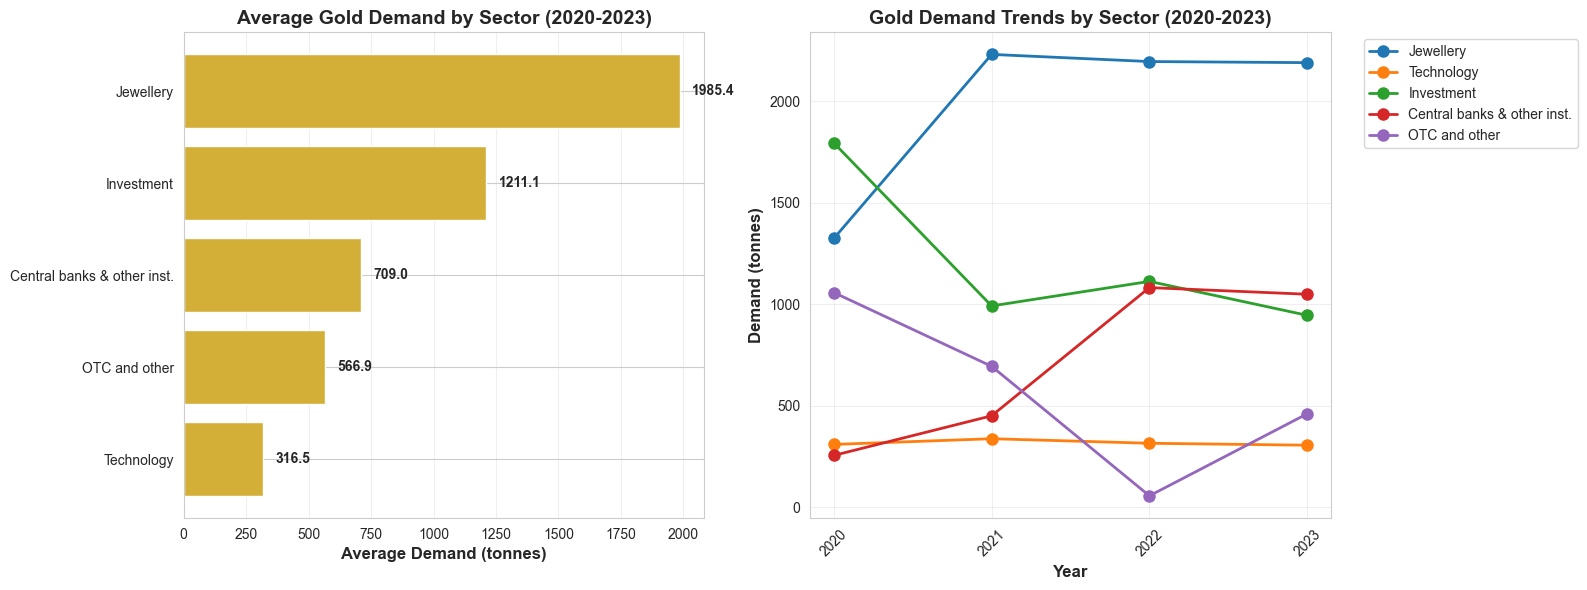

In [4]:
# ============================================
# 1. DEMAND BY SECTOR VISUALIZATIONS
# ============================================

# Clean numeric columns (remove commas and convert to float)
for col in ['2020', '2021', '2022', '2023', 'average']:
    if col in demand_by_sector.columns:
        demand_by_sector[col] = demand_by_sector[col].astype(str).str.replace(',', '').astype(float)

# Filter out 'Total demand' row for better visualization
sector_data = demand_by_sector[demand_by_sector['sector'] != 'Total demand'].copy()

# 1.1 Bar chart: Average demand by sector
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sector_data_sorted = sector_data.sort_values('average', ascending=True)
axes[0].barh(sector_data_sorted['sector'], sector_data_sorted['average'], color='#D4AF37')
axes[0].set_xlabel('Average Demand (tonnes)', fontsize=12, fontweight='bold')
axes[0].set_title('Average Gold Demand by Sector (2020-2023)', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(sector_data_sorted['average']):
    axes[0].text(v + 50, i, f'{v:.1f}', va='center', fontweight='bold')

# 1.2 Line chart: Demand trends by sector over years
years = ['2020', '2021', '2022', '2023']
for sector in sector_data['sector']:
    values = [sector_data[sector_data['sector'] == sector][year].values[0] for year in years]
    axes[1].plot(years, values, marker='o', linewidth=2, label=sector, markersize=8)

axes[1].set_xlabel('Year', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Demand (tonnes)', fontsize=12, fontweight='bold')
axes[1].set_title('Gold Demand Trends by Sector (2020-2023)', fontsize=14, fontweight='bold')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


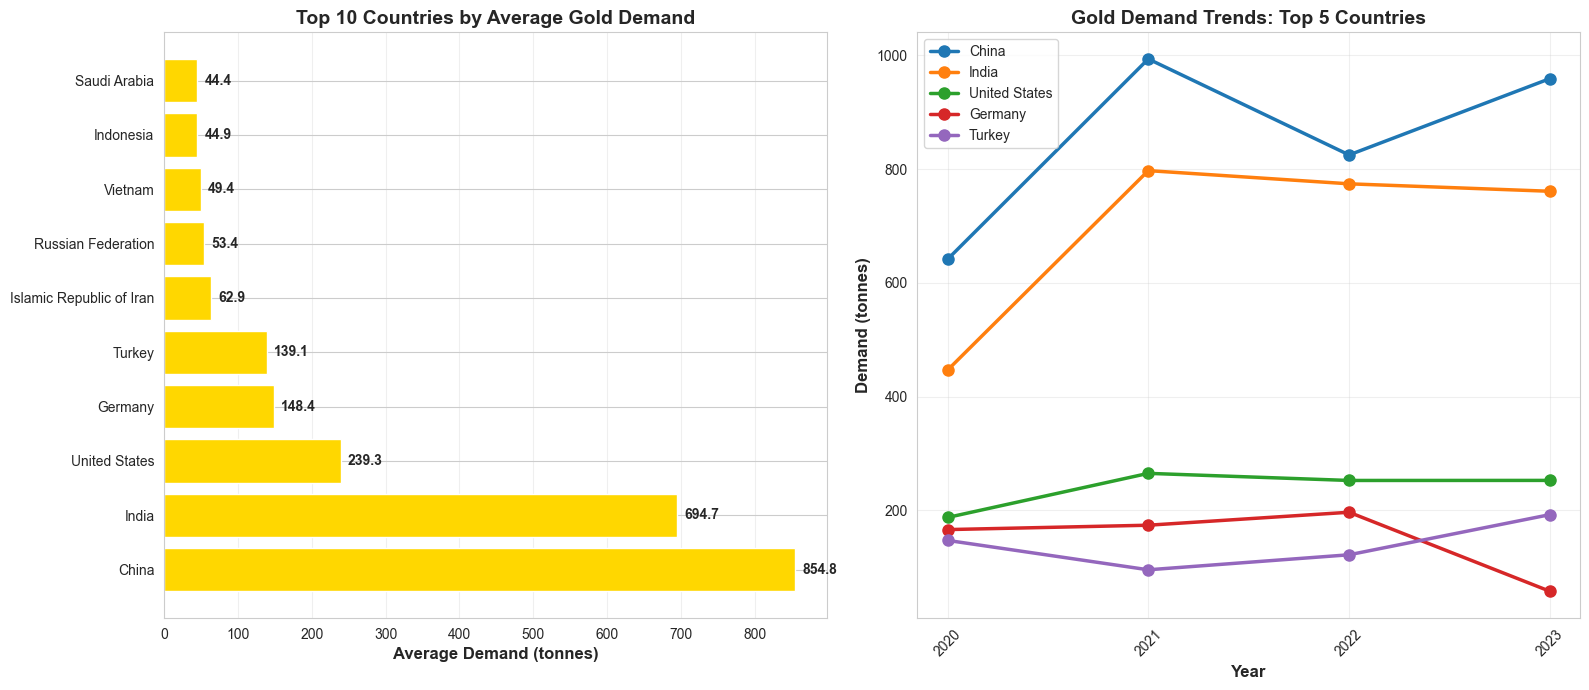

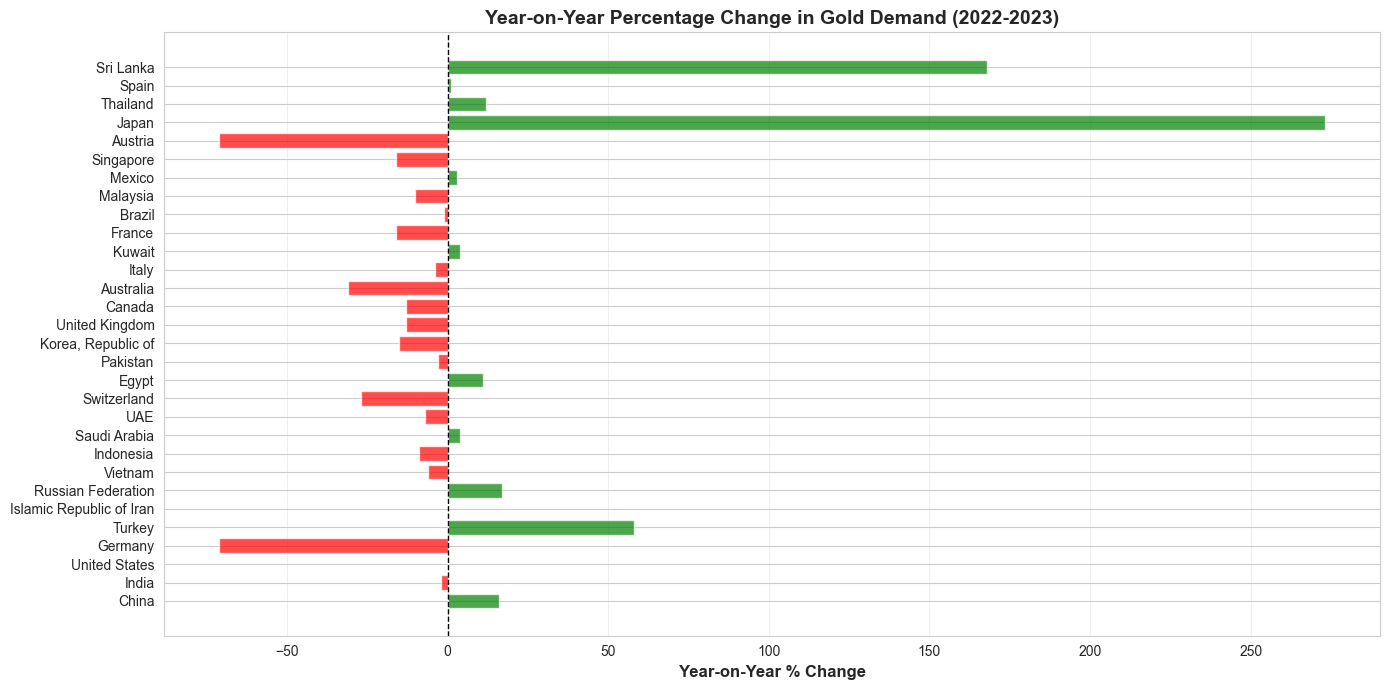

In [5]:
# ============================================
# 2. YEARLY DEMAND VISUALIZATIONS
# ============================================

# Clean column names
yearly_demand.columns = yearly_demand.columns.str.strip()

# Ensure numeric columns are numeric (handle any string values)
numeric_cols = ['2020', '2021', '2022', '2023', 'Average demand']
for col in numeric_cols:
    if col in yearly_demand.columns:
        yearly_demand[col] = pd.to_numeric(yearly_demand[col], errors='coerce')

# 2.1 Top 10 countries by average demand
top_countries = yearly_demand.nlargest(10, 'Average demand')
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(range(len(top_countries)), top_countries['Average demand'], color='#FFD700')
axes[0].set_yticks(range(len(top_countries)))
axes[0].set_yticklabels(top_countries['Countries'])
axes[0].set_xlabel('Average Demand (tonnes)', fontsize=12, fontweight='bold')
axes[0].set_title('Top 10 Countries by Average Gold Demand', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(top_countries['Average demand']):
    axes[0].text(v + 10, i, f'{v:.1f}', va='center', fontweight='bold')

# 2.2 Line chart: Demand trends for top 5 countries
top_5_countries = yearly_demand.nlargest(5, 'Average demand')
years = ['2020', '2021', '2022', '2023']
for idx, row in top_5_countries.iterrows():
    values = [row[year] for year in years]
    axes[1].plot(years, values, marker='o', linewidth=2.5, label=row['Countries'], markersize=8)

axes[1].set_xlabel('Year', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Demand (tonnes)', fontsize=12, fontweight='bold')
axes[1].set_title('Gold Demand Trends: Top 5 Countries', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 2.3 Year-on-year change visualization
fig, ax = plt.subplots(figsize=(14, 7))
colors = ['green' if x >= 0 else 'red' for x in yearly_demand['Year-on-year % change']]
bars = ax.barh(range(len(yearly_demand)), yearly_demand['Year-on-year % change'], color=colors, alpha=0.7)
ax.set_yticks(range(len(yearly_demand)))
ax.set_yticklabels(yearly_demand['Countries'])
ax.set_xlabel('Year-on-Year % Change', fontsize=12, fontweight='bold')
ax.set_title('Year-on-Year Percentage Change in Gold Demand (2022-2023)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

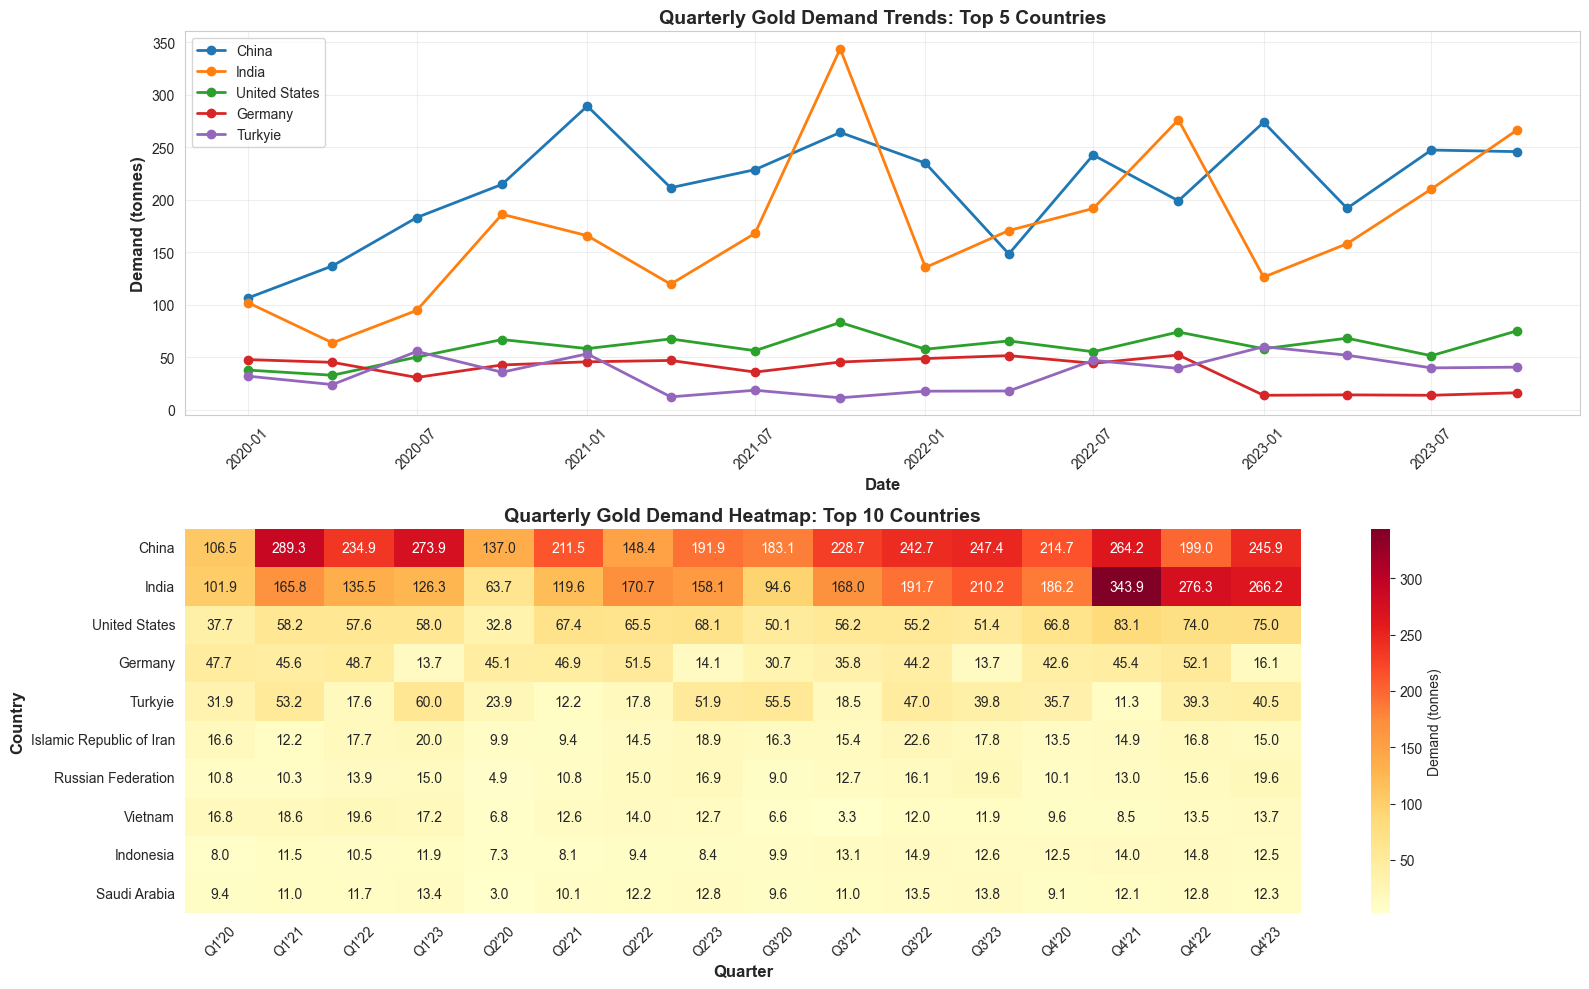

In [6]:
# ============================================
# 3. QUARTERLY DEMAND VISUALIZATIONS
# ============================================

# Ensure demand_tonnes is numeric
quarterly_demand['demand_tonnes'] = pd.to_numeric(quarterly_demand['demand_tonnes'], errors='coerce')

# Parse quarter to extract year and quarter number for sorting
quarterly_demand['year'] = quarterly_demand['quarter'].str.extract(r"(\d{2})")
quarterly_demand['q_num'] = quarterly_demand['quarter'].str.extract(r"Q(\d)")
quarterly_demand['year'] = quarterly_demand['year'].astype(int) + 2000
quarterly_demand['q_num'] = quarterly_demand['q_num'].astype(int)
quarterly_demand['date'] = pd.to_datetime(quarterly_demand['year'].astype(str) + '-' + 
                                          (quarterly_demand['q_num'] * 3 - 2).astype(str) + '-01')
quarterly_demand = quarterly_demand.sort_values('date')

# Filter out negative values (likely data errors)
quarterly_demand_clean = quarterly_demand[quarterly_demand['demand_tonnes'] >= 0].copy()

# 3.1 Time series for top 5 countries
top_5_quarterly = quarterly_demand_clean.groupby('country')['demand_tonnes'].sum().nlargest(5).index
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for country in top_5_quarterly:
    country_data = quarterly_demand_clean[quarterly_demand_clean['country'] == country].sort_values('date')
    axes[0].plot(country_data['date'], country_data['demand_tonnes'], marker='o', linewidth=2, label=country, markersize=6)

axes[0].set_xlabel('Date', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Demand (tonnes)', fontsize=12, fontweight='bold')
axes[0].set_title('Quarterly Gold Demand Trends: Top 5 Countries', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# 3.2 Heatmap: Quarterly demand by country (top 10)
top_10_quarterly = quarterly_demand_clean.groupby('country')['demand_tonnes'].sum().nlargest(10).index
heatmap_data = quarterly_demand_clean[quarterly_demand_clean['country'].isin(top_10_quarterly)].pivot_table(
    values='demand_tonnes', index='country', columns='quarter', aggfunc='sum'
)
heatmap_data = heatmap_data.reindex(top_10_quarterly)

sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Demand (tonnes)'}, ax=axes[1])
axes[1].set_title('Quarterly Gold Demand Heatmap: Top 10 Countries', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Quarter', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Country', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

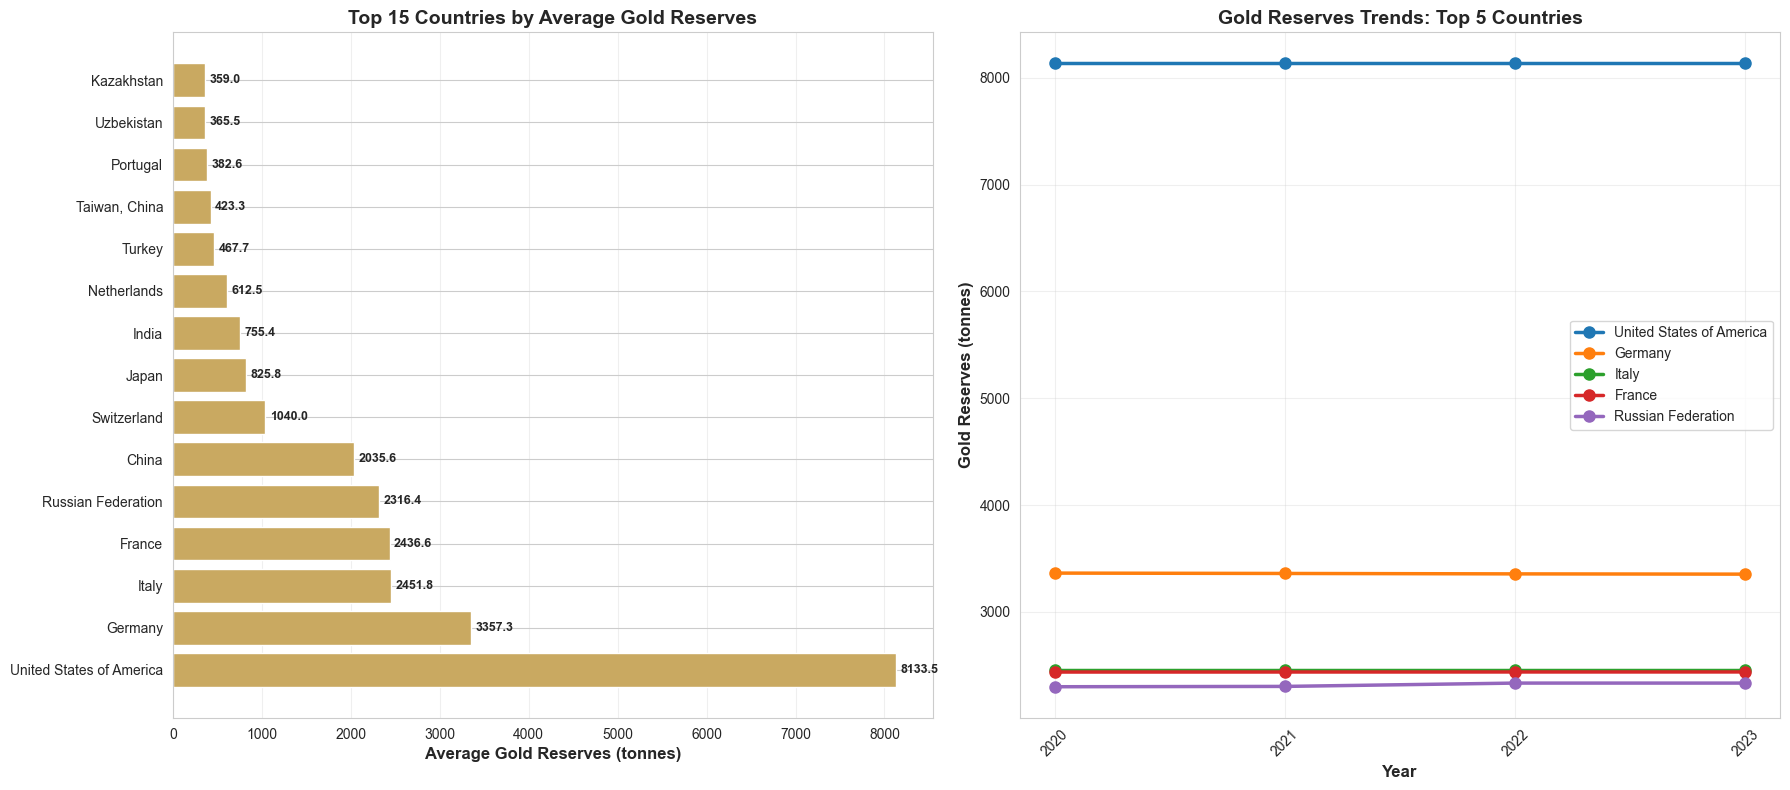

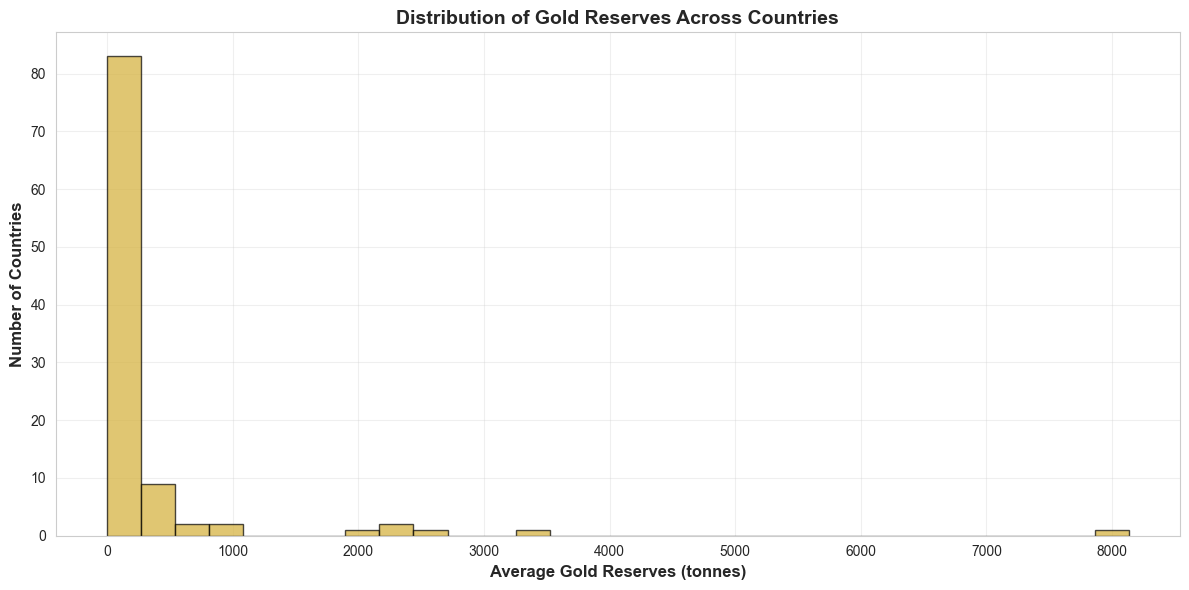

In [7]:
# ============================================
# 4. GOLD RESERVES VISUALIZATIONS
# ============================================

# Clean column names
reserves.columns = reserves.columns.str.strip()

# Ensure numeric columns are numeric
numeric_cols_reserves = ['2020', '2021', '2022', '2023', 'Average gold reserves']
for col in numeric_cols_reserves:
    if col in reserves.columns:
        reserves[col] = pd.to_numeric(reserves[col], errors='coerce')

# 4.1 Top 15 countries by average gold reserves
top_reserves = reserves.nlargest(15, 'Average gold reserves')
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].barh(range(len(top_reserves)), top_reserves['Average gold reserves'], color='#C9A961')
axes[0].set_yticks(range(len(top_reserves)))
axes[0].set_yticklabels(top_reserves['country'])
axes[0].set_xlabel('Average Gold Reserves (tonnes)', fontsize=12, fontweight='bold')
axes[0].set_title('Top 15 Countries by Average Gold Reserves', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(top_reserves['Average gold reserves']):
    axes[0].text(v + 50, i, f'{v:.1f}', va='center', fontweight='bold', fontsize=9)

# 4.2 Reserves trends for top 5 countries
top_5_reserves = reserves.nlargest(5, 'Average gold reserves')
years = ['2020', '2021', '2022', '2023']
for idx, row in top_5_reserves.iterrows():
    values = [row[year] for year in years]
    axes[1].plot(years, values, marker='o', linewidth=2.5, label=row['country'], markersize=8)

axes[1].set_xlabel('Year', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Gold Reserves (tonnes)', fontsize=12, fontweight='bold')
axes[1].set_title('Gold Reserves Trends: Top 5 Countries', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 4.3 Distribution of gold reserves
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(reserves['Average gold reserves'], bins=30, color='#D4AF37', edgecolor='black', alpha=0.7)
ax.set_xlabel('Average Gold Reserves (tonnes)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Countries', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Gold Reserves Across Countries', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

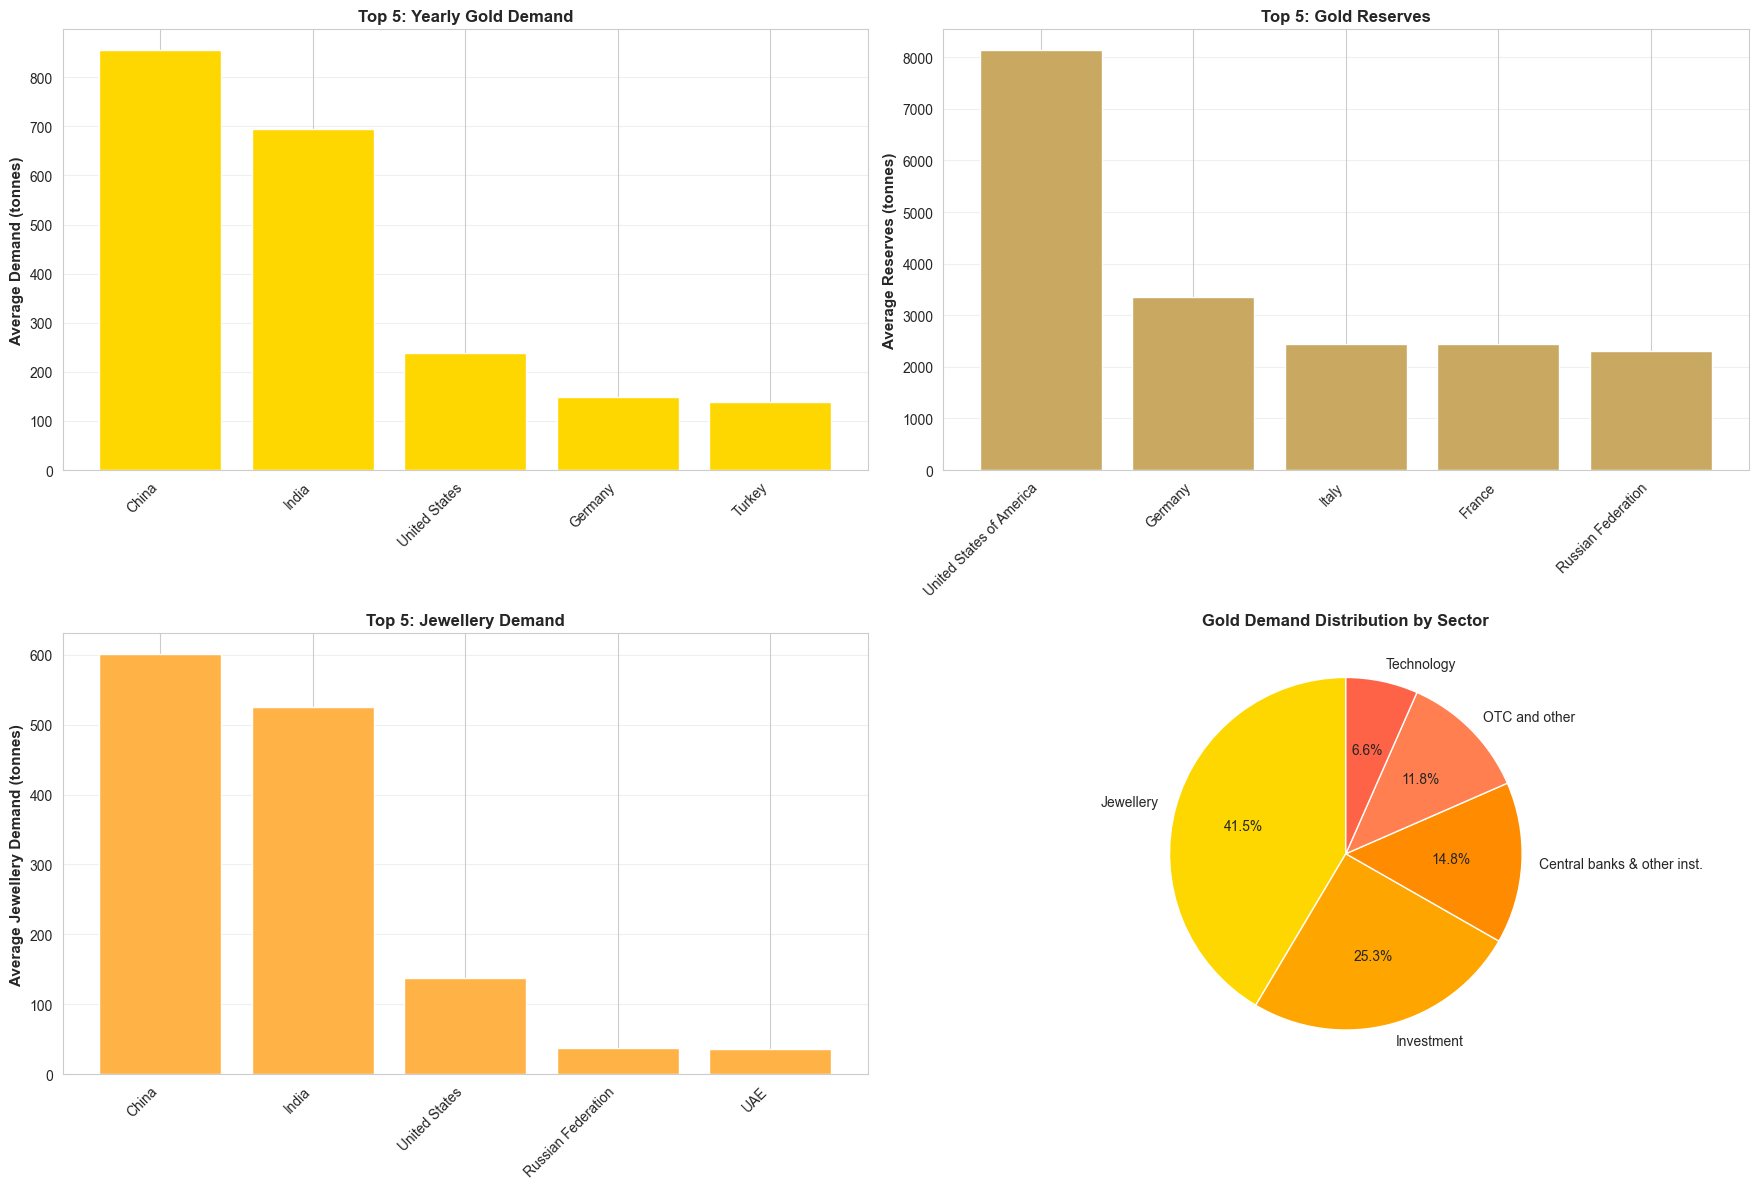

In [10]:
# Compare top countries across different metrics
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top 5 by yearly demand
top_yearly = yearly_demand.nlargest(5, 'Average demand')
axes[0, 0].bar(range(len(top_yearly)), top_yearly['Average demand'], color='#FFD700')
axes[0, 0].set_xticks(range(len(top_yearly)))
axes[0, 0].set_xticklabels(top_yearly['Countries'], rotation=45, ha='right')
axes[0, 0].set_ylabel('Average Demand (tonnes)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Top 5: Yearly Gold Demand', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Top 5 by reserves
top_reserves_5 = reserves.nlargest(5, 'Average gold reserves')
axes[0, 1].bar(range(len(top_reserves_5)), top_reserves_5['Average gold reserves'], color='#C9A961')
axes[0, 1].set_xticks(range(len(top_reserves_5)))
axes[0, 1].set_xticklabels(top_reserves_5['country'], rotation=45, ha='right')
axes[0, 1].set_ylabel('Average Reserves (tonnes)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Top 5: Gold Reserves', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Top 5 by jewellery demand
top_jewellery_5 = jewellery_by_country.nlargest(5, 'Average')
axes[1, 0].bar(range(len(top_jewellery_5)), top_jewellery_5['Average'], color='#FFB347')
axes[1, 0].set_xticks(range(len(top_jewellery_5)))
axes[1, 0].set_xticklabels(top_jewellery_5['country'], rotation=45, ha='right')
axes[1, 0].set_ylabel('Average Jewellery Demand (tonnes)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Top 5: Jewellery Demand', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Sector comparison pie chart
sector_pie = sector_data.sort_values('average', ascending=False)
axes[1, 1].pie(sector_pie['average'], labels=sector_pie['sector'], autopct='%1.1f%%', 
               startangle=90, colors=['#FFD700', '#FFA500', '#FF8C00', '#FF7F50', '#FF6347'])
axes[1, 1].set_title('Gold Demand Distribution by Sector', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()